# Knowledge Graph RAG

## What is Knowledge Graph RAG?

Instead of searching **chunks of text** (like basic RAG), Knowledge Graph RAG:
1. **Extracts entities and relationships** from text (e.g., "Elon Musk" → CEO of → "Tesla")
2. **Builds a graph** where nodes = entities, edges = relationships
3. **Queries the graph** to find connected information and answer questions

### Why Knowledge Graph RAG?

| Feature | Basic RAG | Knowledge Graph RAG |
|---|---|---|
| Storage | Text chunks | Entities + Relationships |
| Search | Similarity search | Graph traversal |
| Strength | Good for general questions | Great for relationship questions |
| Example | "Tell me about Elon Musk" | "What companies does Elon Musk run and what do they build?" |

### Flow
```
Text → Extract Entities & Relations → Build Graph → Query Graph → LLM Answer
```

# ⚠️ IMPORTANT: Educational Implementation — Not Production Ready

This notebook demonstrates a **simplified implementation of Knowledge Graph RAG (KG-RAG)** built from scratch for **learning and understanding purposes only**.

---

## 🚫 Do NOT Treat This as a Production System

This implementation:

* Uses **manual triplet extraction via LLM prompts**
* Stores the graph using **NetworkX (in-memory)**
* Uses **basic string matching** for entity resolution
* Performs **limited (1-hop) graph retrieval**

👉 These choices are intentionally simplified to help you understand the core concepts.

---

## ⚠️ Key Limitations

* ❌ Not scalable for large datasets
* ❌ No persistent graph database (e.g., Neo4j)
* ❌ No advanced entity disambiguation
* ❌ No multi-hop reasoning or optimization
* ❌ No performance optimization or caching
* ❌ Not suitable for real-world applications

---

## ✅ What This Notebook Teaches

This notebook is designed to help you understand:

* How text is converted into **(subject, relation, object) triplets**
* How triplets form a **knowledge graph (nodes + edges)**
* How **graph-based retrieval** works
* How LLMs use structured knowledge to generate answers

---

## 🏭 How Real-World Systems Differ

Production-grade KG-RAG systems use:

* **Graph frameworks** (e.g., Graphiti, LlamaIndex Graph)
* **Graph databases** (e.g., Neo4j, Neptune)
* **Advanced entity matching** (embeddings, NER pipelines)
* **Multi-hop reasoning and optimized traversal**
* **Scalable architectures and pipelines**

---

## 🔁 Learning Path

1. Understand this implementation (fundamentals)
2. Then move to **framework-based systems (e.g., Graphiti)**
3. Then build **scalable production architectures**

---

## 🧠 Key Takeaway

> This notebook helps you understand *how KG-RAG works internally*.
> In real-world systems, we **do not build everything manually** — we use specialized frameworks and infrastructure.

---


In [14]:
# Step 1: Check Python path and install if needed
import sys
print(sys.executable)
print(sys.version)

d:\genai\.venv\Scripts\python.exe
3.14.0 (tags/v3.14.0:ebf955d, Oct  7 2025, 10:15:03) [MSC v.1944 64 bit (AMD64)]


In [15]:
# Step 2: Imports and setup
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
import networkx as nx
import json
import os

load_dotenv()

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

In [16]:
# Step 3: Load the document
with open("document.txt", "r", encoding="utf-8") as f:
    text = f.read()

print(text[:300], "...")

Elon Musk is the CEO of Tesla. Elon Musk is the CEO of SpaceX. Elon Musk is the owner of X, formerly known as Twitter. Elon Musk founded The Boring Company. Elon Musk co-founded Neuralink. Elon Musk co-founded OpenAI. Elon Musk was born in Pretoria, South Africa. Elon Musk holds citizenship in South ...


## Step 4: Extract Entities & Relationships using LLM

This is the **key step** — we ask the LLM to read the text and pull out:
- **Subject** (entity 1)
- **Relationship** (how they're connected)
- **Object** (entity 2)

Example: `("Elon Musk", "is CEO of", "Tesla")`

In [17]:
# Step 4: Extract triplets (subject, relationship, object) from text

def extract_triplets(text):
    """Use LLM to extract (subject, relationship, object) triplets from text."""
    response = llm.invoke(f"""
Extract all entity relationships from this text as a JSON list of triplets.
Each triplet should be: ["subject", "relationship", "object"]

Rules:
- Use consistent entity names (e.g., always "Elon Musk" not sometimes "Musk")
- Keep relationships short and clear (e.g., "is CEO of", "founded", "developed")
- Extract ALL relationships mentioned in the text

Return ONLY a valid JSON list, nothing else. No markdown, no code blocks.

Text:
{text}
""")

    content = response.content.strip()
    # Remove markdown code block wrapper if present
    if content.startswith("```"):
        content = content.split("\n", 1)[1]  # remove first line (```json)
        content = content.rsplit("```", 1)[0]  # remove closing ```
        content = content.strip()

    triplets = json.loads(content)
    return triplets


triplets = extract_triplets(text)

print(f"Extracted {len(triplets)} relationships:\n")
for t in triplets:
    print(f"  {t[0]}  --[{t[1]}]-->  {t[2]}")

Extracted 35 relationships:

  Elon Musk  --[is CEO of]-->  Tesla
  Elon Musk  --[is CEO of]-->  SpaceX
  Elon Musk  --[is owner of]-->  X
  Elon Musk  --[founded]-->  The Boring Company
  Elon Musk  --[co-founded]-->  Neuralink
  Elon Musk  --[co-founded]-->  OpenAI
  Elon Musk  --[was born in]-->  Pretoria, South Africa
  Elon Musk  --[holds citizenship in]-->  South Africa
  Elon Musk  --[holds citizenship in]-->  Canada
  Elon Musk  --[holds citizenship in]-->  the United States
  Tesla  --[is]-->  an electric vehicle and clean energy company
  Tesla  --[is headquartered in]-->  Austin, Texas
  SpaceX  --[is]-->  a private aerospace manufacturer and space transportation company
  SpaceX  --[developed]-->  the Falcon 9 rocket
  SpaceX  --[developed]-->  the Starship rocket
  Falcon 9  --[is]-->  a reusable orbital rocket
  Starship  --[is designed for]-->  missions to Mars
  The Boring Company  --[builds]-->  underground transportation tunnels
  Neuralink  --[develops]-->  brain-com

## Step 5: Build the Knowledge Graph

We use **NetworkX** to create a directed graph where:
- **Nodes** = Entities (Elon Musk, Tesla, SpaceX...)
- **Edges** = Relationships (is CEO of, founded, developed...)

In [18]:
# Step 5: Build the knowledge graph

graph = nx.DiGraph()

for subject, relation, obj in triplets:
    graph.add_edge(subject, obj, relation=relation)

print(f"Knowledge Graph built!")
print(f"  Nodes (entities): {graph.number_of_nodes()}")
print(f"  Edges (relationships): {graph.number_of_edges()}")
print(f"\nEntities: {list(graph.nodes)}")

Knowledge Graph built!
  Nodes (entities): 37
  Edges (relationships): 35

Entities: ['Elon Musk', 'Tesla', 'SpaceX', 'X', 'The Boring Company', 'Neuralink', 'OpenAI', 'Pretoria, South Africa', 'South Africa', 'Canada', 'the United States', 'an electric vehicle and clean energy company', 'Austin, Texas', 'a private aerospace manufacturer and space transportation company', 'the Falcon 9 rocket', 'the Starship rocket', 'Falcon 9', 'a reusable orbital rocket', 'Starship', 'missions to Mars', 'underground transportation tunnels', 'brain-computer interface technology', 'a social media platform', 'Twitter', 'Twitter to X', 'the University of Pennsylvania', 'Stanford University', 'Kimbal Musk', 'Gwynne Shotwell', 'the Model S', 'the Model 3', 'the Model X', 'the Model Y', 'Gigafactories around the world', 'astronauts to the International Space Station', 'the Hyperloop concept', 'one of the wealthiest people in the world']


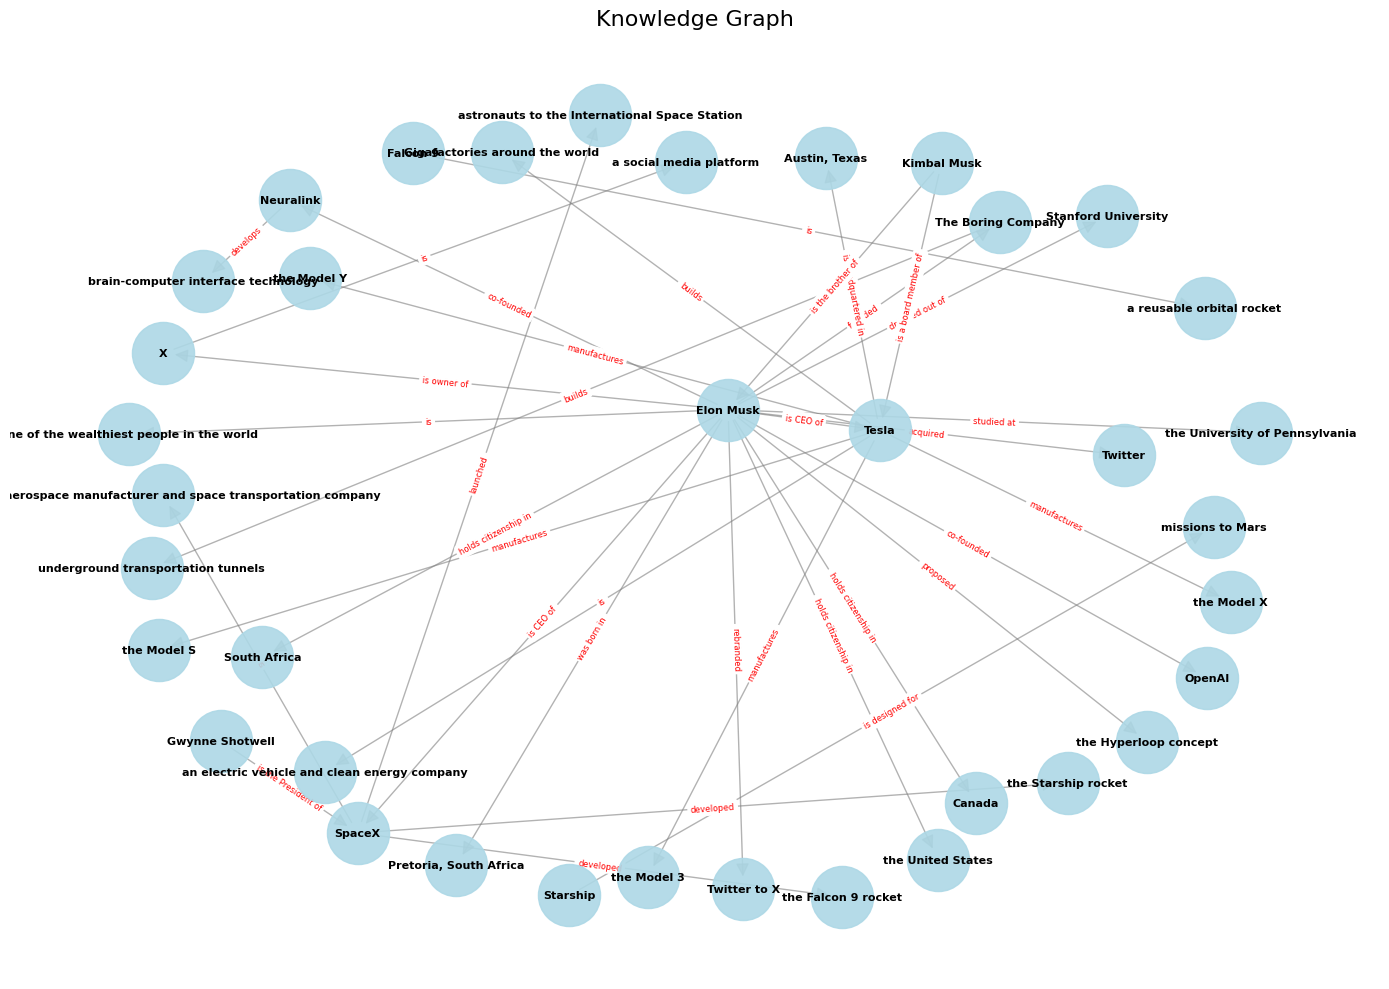

In [19]:
# Step 6: Visualize the Knowledge Graph
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 10))

pos = nx.spring_layout(graph, k=2, seed=42)

# Draw nodes
nx.draw_networkx_nodes(graph, pos, node_color="lightblue", node_size=2000, alpha=0.9)
nx.draw_networkx_labels(graph, pos, font_size=8, font_weight="bold")

# Draw edges with relationship labels
nx.draw_networkx_edges(graph, pos, edge_color="gray", arrows=True, arrowsize=20, alpha=0.6)
edge_labels = nx.get_edge_attributes(graph, "relation")
nx.draw_networkx_edge_labels(graph, pos, edge_labels=edge_labels, font_size=6, font_color="red")

plt.title("Knowledge Graph", fontsize=16)
plt.axis("off")
plt.tight_layout()
plt.show()

## Step 7: Query the Knowledge Graph

Now the key part — when a user asks a question:
1. **LLM extracts entities** from the question
2. **Search the graph** for those entities and their neighbors
3. **Collect all related facts** as context
4. **LLM generates answer** using graph context

In [20]:
# Step 7: Query functions

def get_entity_context(graph, entity):
    """Get all facts related to an entity from the graph."""
    facts = []

    # Outgoing edges: entity --[relation]--> other
    for _, target, data in graph.out_edges(entity, data=True):
        facts.append(f"{entity} {data['relation']} {target}")

    # Incoming edges: other --[relation]--> entity
    for source, _, data in graph.in_edges(entity, data=True):
        facts.append(f"{source} {data['relation']} {entity}")

    return facts


def find_matching_entities(graph, query_entities):
    """Match extracted entity names to graph nodes (case-insensitive)."""
    matched = []
    graph_nodes = list(graph.nodes)

    for qe in query_entities:
        for node in graph_nodes:
            if qe.lower() in node.lower() or node.lower() in qe.lower():
                matched.append(node)

    return list(set(matched))


def parse_json_response(text):
    """Parse JSON from LLM response, handling markdown code blocks."""
    text = text.strip()
    if text.startswith("```"):
        text = text.split("\n", 1)[1]
        text = text.rsplit("```", 1)[0]
        text = text.strip()
    return json.loads(text)


def knowledge_graph_rag(query):
    """Full KG-RAG pipeline: question → extract entities → search graph → answer."""

    # Step 1: Extract entities from the question
    entity_response = llm.invoke(f"""
Extract the key entity names from this question.
Return ONLY a JSON list of strings, nothing else. No markdown, no code blocks.
Question: {query}
""")
    query_entities = parse_json_response(entity_response.content)
    print(f"Entities found in question: {query_entities}")

    # Step 2: Find matching entities in the graph
    matched = find_matching_entities(graph, query_entities)
    print(f"Matched in graph: {matched}")

    # Step 3: Collect facts from the graph (include neighbors for richer context)
    all_facts = []
    visited = set()

    for entity in matched:
        if entity not in visited:
            visited.add(entity)
            all_facts.extend(get_entity_context(graph, entity))

            # Also get 1-hop neighbors for richer context
            for neighbor in list(graph.successors(entity)) + list(graph.predecessors(entity)):
                if neighbor not in visited:
                    visited.add(neighbor)
                    all_facts.extend(get_entity_context(graph, neighbor))

    unique_facts = list(set(all_facts))
    context = "\n".join(unique_facts)

    print(f"\nGraph facts retrieved ({len(unique_facts)}):")
    for f in unique_facts:
        print(f"  - {f}")

    # Step 4: Generate answer using graph context
    answer = llm.invoke(f"""
Answer the question using ONLY the knowledge graph facts below.
If the facts don't contain enough info, say so.

Knowledge Graph Facts:
{context}

Question: {query}
Answer:
""").content.strip()

    return answer

In [21]:
# Test 1: Simple entity question
print("=" * 60)
print("Q: Who is Elon Musk?")
print("=" * 60)
answer = knowledge_graph_rag("Who is Elon Musk?")
print(f"\nAnswer: {answer}")

Q: Who is Elon Musk?
Entities found in question: ['Elon Musk']
Matched in graph: ['Elon Musk']

Graph facts retrieved (33):
  - Tesla manufactures the Model S
  - Elon Musk acquired Twitter
  - Elon Musk proposed the Hyperloop concept
  - Elon Musk is one of the wealthiest people in the world
  - Elon Musk is CEO of Tesla
  - Tesla manufactures the Model Y
  - Tesla builds Gigafactories around the world
  - Elon Musk holds citizenship in Canada
  - Elon Musk founded The Boring Company
  - Kimbal Musk is a board member of Tesla
  - Elon Musk was born in Pretoria, South Africa
  - Elon Musk dropped out of Stanford University
  - Elon Musk holds citizenship in South Africa
  - Elon Musk holds citizenship in the United States
  - Tesla manufactures the Model X
  - Elon Musk is owner of X
  - Elon Musk rebranded Twitter to X
  - Elon Musk is CEO of SpaceX
  - Neuralink develops brain-computer interface technology
  - The Boring Company builds underground transportation tunnels
  - SpaceX de

In [22]:
# Test 2: Relationship question (this is where KG RAG shines!)
print("=" * 60)
print("Q: What companies does Elon Musk run and what do they build?")
print("=" * 60)
answer = knowledge_graph_rag("What companies does Elon Musk run and what do they build?")
print(f"\nAnswer: {answer}")

Q: What companies does Elon Musk run and what do they build?
Entities found in question: ['Elon Musk', 'companies']
Matched in graph: ['Elon Musk']

Graph facts retrieved (33):
  - Tesla manufactures the Model S
  - Elon Musk acquired Twitter
  - Elon Musk proposed the Hyperloop concept
  - Elon Musk is one of the wealthiest people in the world
  - Elon Musk is CEO of Tesla
  - Tesla manufactures the Model Y
  - Tesla builds Gigafactories around the world
  - Elon Musk holds citizenship in Canada
  - Elon Musk founded The Boring Company
  - Kimbal Musk is a board member of Tesla
  - Elon Musk was born in Pretoria, South Africa
  - Elon Musk dropped out of Stanford University
  - Elon Musk holds citizenship in South Africa
  - Elon Musk holds citizenship in the United States
  - Tesla manufactures the Model X
  - Elon Musk is owner of X
  - Elon Musk rebranded Twitter to X
  - Elon Musk is CEO of SpaceX
  - Neuralink develops brain-computer interface technology
  - The Boring Company bu

In [23]:
# Test 3: Multi-hop question
print("=" * 60)
print("Q: Who is the president of SpaceX and what rockets has SpaceX developed?")
print("=" * 60)
answer = knowledge_graph_rag("Who is the president of SpaceX and what rockets has SpaceX developed?")
print(f"\nAnswer: {answer}")

Q: Who is the president of SpaceX and what rockets has SpaceX developed?
Entities found in question: ['president of SpaceX', 'SpaceX', 'rockets']
Matched in graph: ['X', 'SpaceX']

Graph facts retrieved (23):
  - Elon Musk acquired Twitter
  - Elon Musk proposed the Hyperloop concept
  - Elon Musk is one of the wealthiest people in the world
  - Elon Musk is CEO of Tesla
  - Elon Musk holds citizenship in Canada
  - Elon Musk founded The Boring Company
  - Elon Musk was born in Pretoria, South Africa
  - Elon Musk dropped out of Stanford University
  - Elon Musk holds citizenship in South Africa
  - Elon Musk holds citizenship in the United States
  - Elon Musk is owner of X
  - Elon Musk rebranded Twitter to X
  - Elon Musk is CEO of SpaceX
  - SpaceX developed the Falcon 9 rocket
  - Elon Musk studied at the University of Pennsylvania
  - SpaceX developed the Starship rocket
  - X is a social media platform
  - SpaceX is a private aerospace manufacturer and space transportation compa

In [24]:
# Test 4: List all related entities
print("=" * 60)
print("Q: What cars does Tesla manufacture?")
print("=" * 60)
answer = knowledge_graph_rag("What cars does Tesla manufacture?")
print(f"\nAnswer: {answer}")

Q: What cars does Tesla manufacture?
Entities found in question: ['Tesla', 'cars']
Matched in graph: ['Tesla']

Graph facts retrieved (25):
  - Tesla manufactures the Model S
  - Elon Musk acquired Twitter
  - Elon Musk proposed the Hyperloop concept
  - Elon Musk is one of the wealthiest people in the world
  - Elon Musk is CEO of Tesla
  - Tesla manufactures the Model Y
  - Tesla builds Gigafactories around the world
  - Elon Musk holds citizenship in Canada
  - Elon Musk founded The Boring Company
  - Kimbal Musk is a board member of Tesla
  - Elon Musk was born in Pretoria, South Africa
  - Elon Musk dropped out of Stanford University
  - Elon Musk holds citizenship in South Africa
  - Elon Musk holds citizenship in the United States
  - Tesla manufactures the Model X
  - Elon Musk is owner of X
  - Elon Musk rebranded Twitter to X
  - Elon Musk is CEO of SpaceX
  - Tesla manufactures the Model 3
  - Elon Musk studied at the University of Pennsylvania
  - Tesla is headquartered in 

In [25]:
# Test 5: Family and personal connections
print("=" * 60)
print("Q: Who is Kimbal Musk and how is he connected to Elon Musk?")
print("=" * 60)
answer = knowledge_graph_rag("Who is Kimbal Musk and how is he connected to Elon Musk?")
print(f"\nAnswer: {answer}")

Q: Who is Kimbal Musk and how is he connected to Elon Musk?
Entities found in question: ['Kimbal Musk', 'Elon Musk']
Matched in graph: ['Kimbal Musk', 'Elon Musk']

Graph facts retrieved (25):
  - Tesla manufactures the Model S
  - Elon Musk acquired Twitter
  - Elon Musk proposed the Hyperloop concept
  - Elon Musk is one of the wealthiest people in the world
  - Elon Musk is CEO of Tesla
  - Tesla manufactures the Model Y
  - Tesla builds Gigafactories around the world
  - Elon Musk holds citizenship in Canada
  - Elon Musk founded The Boring Company
  - Kimbal Musk is a board member of Tesla
  - Elon Musk was born in Pretoria, South Africa
  - Elon Musk dropped out of Stanford University
  - Elon Musk holds citizenship in South Africa
  - Elon Musk holds citizenship in the United States
  - Tesla manufactures the Model X
  - Elon Musk is owner of X
  - Elon Musk rebranded Twitter to X
  - Elon Musk is CEO of SpaceX
  - Elon Musk studied at the University of Pennsylvania
  - Tesla ma

## How Knowledge Graph RAG Works — Summary

```
                    KNOWLEDGE GRAPH RAG FLOW

   Text Document
        │
        ▼
   LLM extracts triplets:  (Subject) --[Relation]--> (Object)
        │
        ▼
   Build Graph:  Nodes = Entities,  Edges = Relationships
        │
        ▼
   User Question
        │
        ▼
   Extract entities from question
        │
        ▼
   Search graph for matching entities + neighbors
        │
        ▼
   Collect related facts as context
        │
        ▼
   LLM generates answer from graph facts
```

### When to use Knowledge Graph RAG vs Basic RAG?

| Use Case | Best Approach |
|---|---|
| General Q&A from documents | Basic RAG |
| "How are X and Y related?" | Knowledge Graph RAG |
| Multi-hop reasoning | Knowledge Graph RAG |
| Simple fact lookup | Basic RAG |
| Complex entity relationships | Knowledge Graph RAG |